In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Amazon.csv")

print(df.head())
print(df.info())

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...      INR  647.

C:\Users\Mario\AppData\Local\Temp\ipykernel_30332\3938730911.py:4: DtypeWarning: Columns (0: Unnamed: 22) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Amazon.csv")


In [7]:
df = df.drop(columns=["index","Order ID","ASIN","SKU","Unnamed: 22"], errors="ignore")
df["Date"] = pd.to_datetime(df["Date"])
df = df.dropna(subset=["Amount","Qty"])

C:\Users\Mario\AppData\Local\Temp\ipykernel_30332\820085160.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [8]:
print(df["Amount"].describe())

count    121180.000000
mean        648.561465
std         281.211687
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64


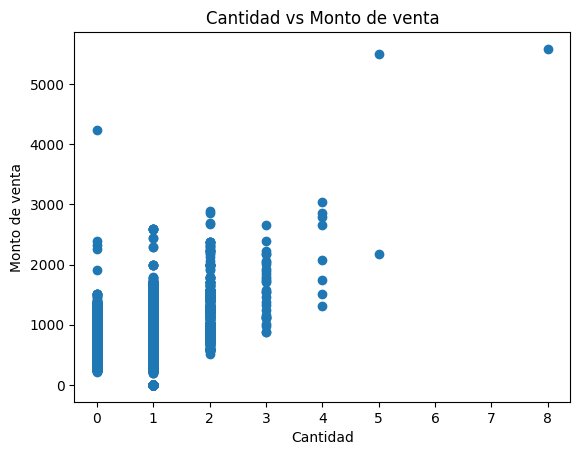

In [9]:
plt.scatter(df["Qty"], df["Amount"])
plt.xlabel("Cantidad")
plt.ylabel("Monto de venta")
plt.title("Cantidad vs Monto de venta")
plt.show()

In [10]:
category_sales = df.groupby("Category")["Amount"].mean().sort_values(ascending=False)

print(category_sales)

Category
Set              833.385571
Saree            799.572645
Western Dress    762.790580
Ethnic Dress     723.895389
Top              526.098603
Blouse           520.327106
kurta            455.927108
Bottom           358.733286
Dupatta          305.000000
Name: Amount, dtype: float64


Top 10 Estados con mayor ticket promedio:
ship-state
bihar          1432.000000
LADAKH          914.010238
Sikkim          901.000000
delhi           827.681000
Chandigarh      823.147273
NAGALAND        801.288659
LAKSHADWEEP     793.822500
SIKKIM          738.639893
Mizoram         735.000000
Punjab          733.766667
Name: Amount, dtype: float64


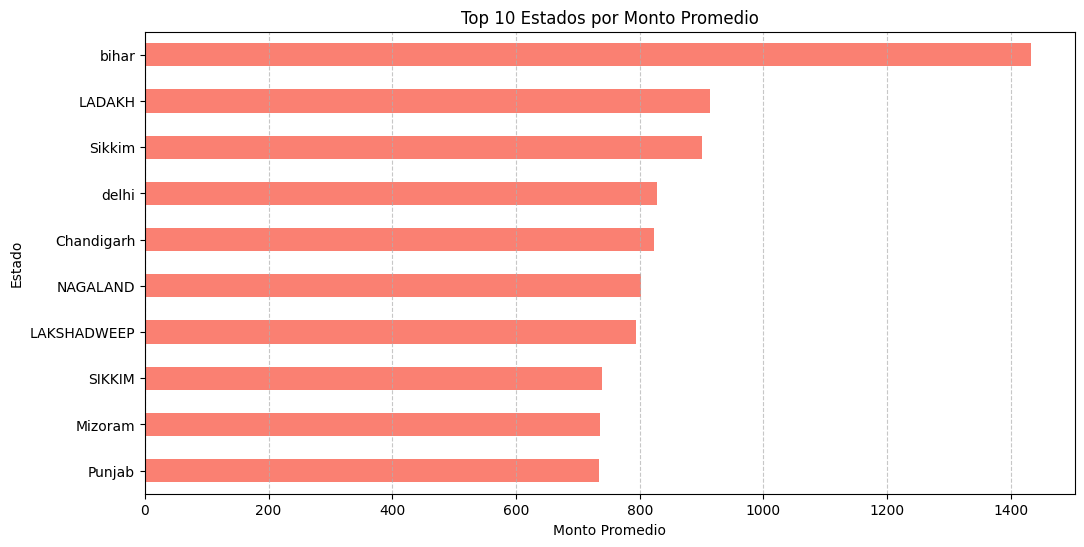

In [11]:
top_states = df.groupby("ship-state")["Amount"].mean().sort_values(ascending=False).head(10)

print("Top 10 Estados con mayor ticket promedio:")
print(top_states)

plt.figure(figsize=(12, 6))
top_states.plot(kind='barh', color='salmon')

plt.title("Top 10 Estados por Monto Promedio")
plt.xlabel("Monto Promedio")
plt.ylabel("Estado")
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comparativa de Monto Promedio: Cliente Final (0) vs B2B (1)
B2B                 False       True 
Category                             
Blouse         521.495052  392.875000
Bottom         358.346899  398.917500
Dupatta        305.000000         NaN
Ethnic Dress   722.203590  845.479333
Saree          799.233725  825.500000
Set            832.856319  908.994190
Top            525.997061  543.200000
Western Dress  762.727389  771.330741
kurta          455.634609  498.470564


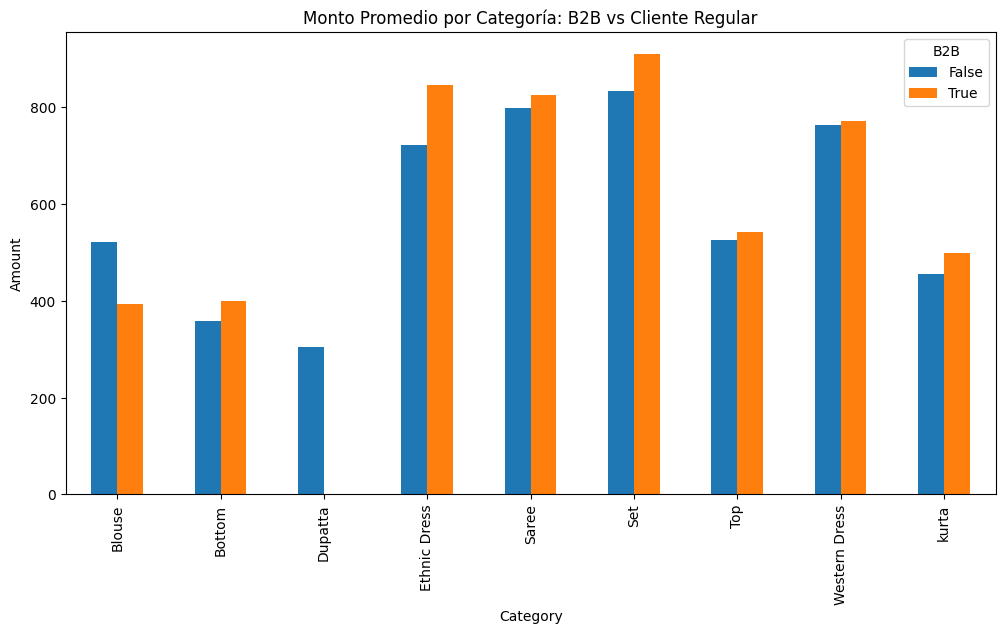

In [12]:
pivot_b2b = df.pivot_table(index='Category', columns='B2B', values='Amount', aggfunc='mean')

print("Comparativa de Monto Promedio: Cliente Final (0) vs B2B (1)")
print(pivot_b2b)


pivot_b2b.plot(kind='bar', figsize=(12, 6))
plt.title("Monto Promedio por Categoría: B2B vs Cliente Regular")
plt.ylabel("Amount")
plt.show()